<a href="https://colab.research.google.com/github/hr9919/Computer-Vision/blob/main/hw3/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 하이퍼파라미터 설정
batch_size = 64
input_size = 784
num_classes = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 로딩 함수
def load_data(dataset='FashionMNIST'):
    if dataset == 'FashionMNIST':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
        train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    elif dataset == 'Digits':
        from sklearn.datasets import load_digits
        from sklearn.model_selection import train_test_split
        digits = load_digits()
        X = digits.images.reshape(-1, 64).astype(np.float32) / 16.0
        y = digits.target
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        train_data = torch.utils.data.TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
        test_data = torch.utils.data.TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
    else:
        raise ValueError("Unknown dataset")

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size)
    return train_loader, test_loader

# MLP 모델 정의
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[256, 128], num_classes=10, activation='relu'):
        super(MLP, self).__init__()
        act_fn = {
            'relu': nn.ReLU(),
            'leakyrelu': nn.LeakyReLU(0.01),
            'sigmoid': nn.Sigmoid()
        }[activation.lower()]

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            act_fn,
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            act_fn,
            nn.Linear(hidden_sizes[1], num_classes)
        )

    def forward(self, x):
        return self.net(x)

# 학습 함수
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=30, use_softmax=False):
    train_loss, test_acc = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            if use_softmax:
                outputs = torch.softmax(outputs, dim=1)
                y_onehot = torch.nn.functional.one_hot(y, num_classes).float()
                loss = loss_fn(outputs, y_onehot)
            else:
                loss = loss_fn(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss.append(total_loss / len(train_loader))

        # 평가
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        acc = correct / total
        test_acc.append(acc)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}, Acc: {acc:.4f}")

    return train_loss, test_acc

# 시각화 함수
def plot_metrics(train_loss, test_acc, title='Experiment'):
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(train_loss, label='Train Loss', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy', color='tab:blue')
    ax2.plot(test_acc, label='Test Accuracy', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title)
    plt.show()

# 실험 A: 손실 함수 비교 — CrossEntropy vs MSE (with Softmax)

### **실험 조건 정리**

- **데이터셋**: Fashion-MNIST
- **모델 구조**: 고정 (256 → 128 → num_classes)
- **활성화 함수**: ReLU
- **Optimizer**: Adam (lr=0.001)
- **Loss Function**:
    - 실험 1: nn.CrossEntropyLoss() (logits + 내부 Softmax)
    - 실험 2: nn.MSELoss() + 출력에 torch.softmax()
- **에폭 수**: 30
- **학습률**: 0.001

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터셋 로드 (Fashion-MNIST)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 2. MLP 모델 정의
class MLP(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, use_softmax=False):
        super().__init__()
        self.use_softmax = use_softmax
        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        out = self.model(x)
        if self.use_softmax:
            return torch.softmax(out, dim=1)
        return out

# 3. 학습 함수
def train(model, loss_fn, optimizer, train_loader, test_loader, epochs=30):
    train_loss_hist, test_acc_hist = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            # MSE requires one-hot targets
            if isinstance(loss_fn, nn.MSELoss):
                target_onehot = torch.zeros(output.size()).scatter_(1, target.view(-1,1), 1.0)
                loss = loss_fn(output, target_onehot)
            else:
                loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss_hist.append(total_loss / len(train_loader))

        # 평가
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                pred = output.argmax(dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)
        test_acc_hist.append(correct / total)

        print(f"Epoch {epoch+1}: Loss={train_loss_hist[-1]:.4f}, Accuracy={test_acc_hist[-1]*100:.2f}%")

    return train_loss_hist, test_acc_hist

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.46MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 136kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.8MB/s]


In [7]:
# 실험 1: CrossEntropyLoss
model_ce = MLP(use_softmax=False)
loss_fn_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)

print("▶ CrossEntropyLoss 학습 시작")
loss_ce, acc_ce = train(model_ce, loss_fn_ce, optimizer_ce, train_loader, test_loader)

# 실험 2: MSELoss + Softmax
model_mse = MLP(use_softmax=True)
loss_fn_mse = nn.MSELoss()
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

print("▶ MSELoss (with Softmax) 학습 시작")
loss_mse, acc_mse = train(model_mse, loss_fn_mse, optimizer_mse, train_loader, test_loader)

▶ CrossEntropyLoss 학습 시작
Epoch 1: Loss=0.5241, Accuracy=84.20%
Epoch 2: Loss=0.3735, Accuracy=85.56%
Epoch 3: Loss=0.3340, Accuracy=86.01%
Epoch 4: Loss=0.3106, Accuracy=86.91%
Epoch 5: Loss=0.2904, Accuracy=87.73%
Epoch 6: Loss=0.2753, Accuracy=87.97%
Epoch 7: Loss=0.2614, Accuracy=87.67%
Epoch 8: Loss=0.2482, Accuracy=88.08%
Epoch 9: Loss=0.2412, Accuracy=88.66%
Epoch 10: Loss=0.2296, Accuracy=88.95%
Epoch 11: Loss=0.2224, Accuracy=88.87%
Epoch 12: Loss=0.2119, Accuracy=88.97%
Epoch 13: Loss=0.2063, Accuracy=88.80%
Epoch 14: Loss=0.1948, Accuracy=89.28%
Epoch 15: Loss=0.1913, Accuracy=88.96%
Epoch 16: Loss=0.1823, Accuracy=89.36%
Epoch 17: Loss=0.1743, Accuracy=88.65%
Epoch 18: Loss=0.1710, Accuracy=88.68%
Epoch 19: Loss=0.1636, Accuracy=89.29%
Epoch 20: Loss=0.1581, Accuracy=89.17%
Epoch 21: Loss=0.1564, Accuracy=89.53%
Epoch 22: Loss=0.1522, Accuracy=89.85%
Epoch 23: Loss=0.1426, Accuracy=89.06%
Epoch 24: Loss=0.1404, Accuracy=88.69%
Epoch 25: Loss=0.1363, Accuracy=89.84%
Epoch 26:

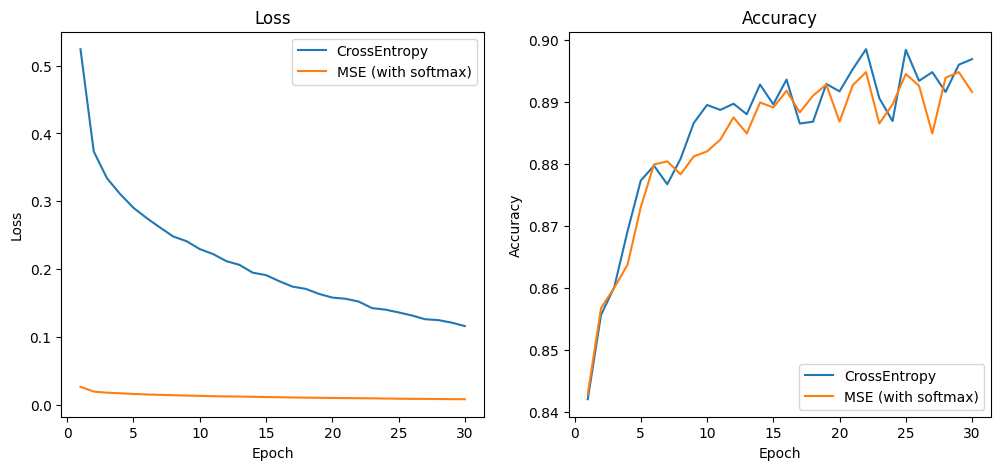

In [13]:
epochs = range(1, 31)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, loss_ce, label='CrossEntropy')
plt.plot(epochs, loss_mse, label='MSE (with softmax)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, acc_ce, label='CrossEntropy')
plt.plot(epochs, acc_mse, label='MSE (with softmax)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.show()

# 실험 B: 활성화 함수 비교 — ReLU vs LeakyReLU vs Sigmoid

### **실험 조건 정리**

- **모델 구조**: 고정 (256 → 128 → 10)
- **데이터셋**: make_moons
- **손실 함수**: CrossEntropyLoss
- **Optimizer**: Adam (lr=0.001)
- **활성화 함수**:
    - ReLU
    - LeakyReLU (0.01)
    - Sigmoid


▶ ReLU 학습 시작
Epoch 1: Loss=1.2937, Accuracy=93.75%
Epoch 2: Loss=0.7371, Accuracy=95.75%
Epoch 3: Loss=0.7501, Accuracy=96.75%
Epoch 4: Loss=0.6888, Accuracy=96.00%
Epoch 5: Loss=0.6875, Accuracy=97.00%
Epoch 6: Loss=0.8061, Accuracy=96.25%
Epoch 7: Loss=0.6281, Accuracy=97.25%
Epoch 8: Loss=0.6338, Accuracy=96.25%
Epoch 9: Loss=1.0926, Accuracy=95.50%
Epoch 10: Loss=0.6031, Accuracy=96.50%
Epoch 11: Loss=0.8397, Accuracy=96.00%
Epoch 12: Loss=0.6611, Accuracy=97.00%
Epoch 13: Loss=0.6681, Accuracy=97.00%
Epoch 14: Loss=0.6822, Accuracy=97.00%
Epoch 15: Loss=0.9580, Accuracy=95.75%
Epoch 16: Loss=0.7866, Accuracy=95.75%
Epoch 17: Loss=0.7585, Accuracy=96.50%
Epoch 18: Loss=0.7807, Accuracy=96.25%
Epoch 19: Loss=0.6244, Accuracy=96.50%
Epoch 20: Loss=0.6384, Accuracy=97.00%
Epoch 21: Loss=0.6086, Accuracy=96.00%
Epoch 22: Loss=0.5963, Accuracy=97.25%
Epoch 23: Loss=0.6146, Accuracy=97.00%
Epoch 24: Loss=0.6783, Accuracy=96.50%
Epoch 25: Loss=0.7080, Accuracy=96.50%
Epoch 26: Loss=0.845

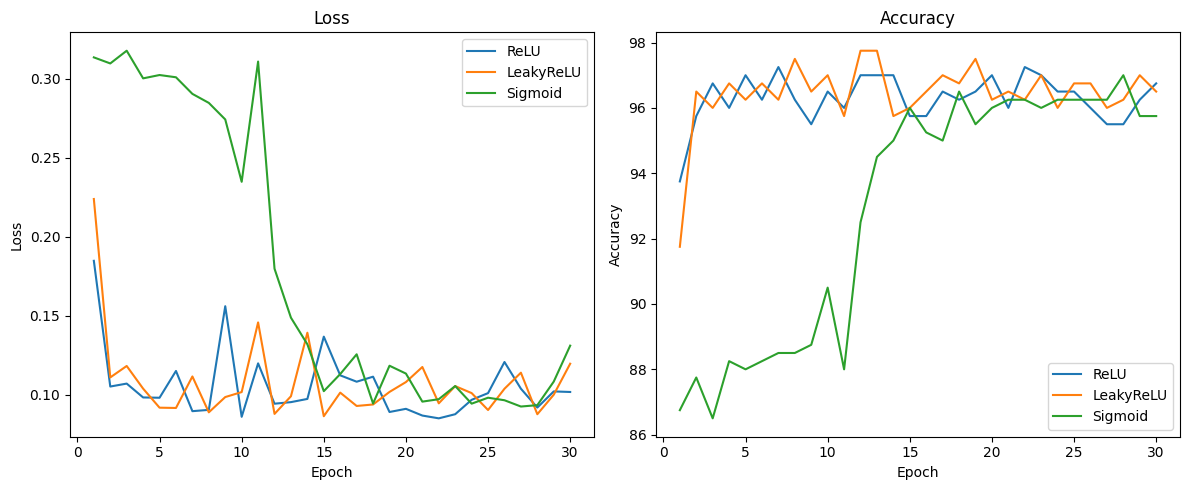

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# 데이터셋 생성 및 전처리
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

# 모델 클래스 정의
class MLP(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            act_fn,
            nn.Linear(64, 64),
            act_fn,
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.model(x)

# 학습 함수
def train(model, loss_fn, optimizer, train_loader, test_loader, epochs=30):
    train_accs = []
    test_accs = []
    losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            loss = loss_fn(output, y_batch)
            loss.backward()
            optimizer.step()

        # 평가
        model.eval()
        correct = 0
        total = 0
        test_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                output = model(x_batch)
                test_loss += loss_fn(output, y_batch).item()
                preds = output.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        acc = correct / total * 100
        test_accs.append(acc)
        losses.append(test_loss / len(test_loader))
        print(f"Epoch {epoch}: Loss={test_loss:.4f}, Accuracy={acc:.2f}%")

    return losses, test_accs

# 실험
def run_experiment(act_fn, name):
    print(f"\n▶ {name} 학습 시작")
    model = MLP(act_fn)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    return train(model, loss_fn, optimizer, train_loader, test_loader)

relu_loss, relu_acc = run_experiment(nn.ReLU(), "ReLU")
leaky_loss, leaky_acc = run_experiment(nn.LeakyReLU(0.01), "LeakyReLU")
sigmoid_loss, sigmoid_acc = run_experiment(nn.Sigmoid(), "Sigmoid")

# 시각화
epochs = range(1, 31)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, relu_loss, label='ReLU')
plt.plot(epochs, leaky_loss, label='LeakyReLU')
plt.plot(epochs, sigmoid_loss, label='Sigmoid')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, relu_acc, label='ReLU')
plt.plot(epochs, leaky_acc, label='LeakyReLU')
plt.plot(epochs, sigmoid_acc, label='Sigmoid')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 실험 C: Optimizer 비교 — SGD vs Momentum vs Adam

### **2. 실험 조건**

| **항목** | **설정값** |
| --- | --- |
| 모델 구조 | 784 → 256 → 128 → 10 |
| 활성화 함수 | ReLU |
| 손실 함수 | CrossEntropyLoss |
| Optimizer | SGD, SGD with Momentum, Adam |
| Epoch 수 | 30 |
| 학습률 | SGD/SGD-Momentum: 0.1, Adam: 0.001 |


[no scheduler] SGD 학습 시작
Epoch 1: Loss=0.9784, Accuracy=77.08%
Epoch 2: Loss=0.5484, Accuracy=80.56%
Epoch 3: Loss=0.4845, Accuracy=82.30%
Epoch 4: Loss=0.4515, Accuracy=82.26%
Epoch 5: Loss=0.4293, Accuracy=83.39%
Epoch 6: Loss=0.4123, Accuracy=83.73%
Epoch 7: Loss=0.3977, Accuracy=82.72%
Epoch 8: Loss=0.3857, Accuracy=84.75%
Epoch 9: Loss=0.3751, Accuracy=84.60%
Epoch 10: Loss=0.3658, Accuracy=85.46%
Epoch 11: Loss=0.3559, Accuracy=85.65%
Epoch 12: Loss=0.3482, Accuracy=86.04%
Epoch 13: Loss=0.3411, Accuracy=85.68%
Epoch 14: Loss=0.3343, Accuracy=85.54%
Epoch 15: Loss=0.3274, Accuracy=85.40%
Epoch 16: Loss=0.3211, Accuracy=86.77%
Epoch 17: Loss=0.3151, Accuracy=86.48%
Epoch 18: Loss=0.3096, Accuracy=87.05%
Epoch 19: Loss=0.3037, Accuracy=86.62%
Epoch 20: Loss=0.2983, Accuracy=87.03%
Epoch 21: Loss=0.2930, Accuracy=87.36%
Epoch 22: Loss=0.2881, Accuracy=87.44%
Epoch 23: Loss=0.2827, Accuracy=87.57%
Epoch 24: Loss=0.2784, Accuracy=87.82%
Epoch 25: Loss=0.2735, Accuracy=87.93%
Epoch 26

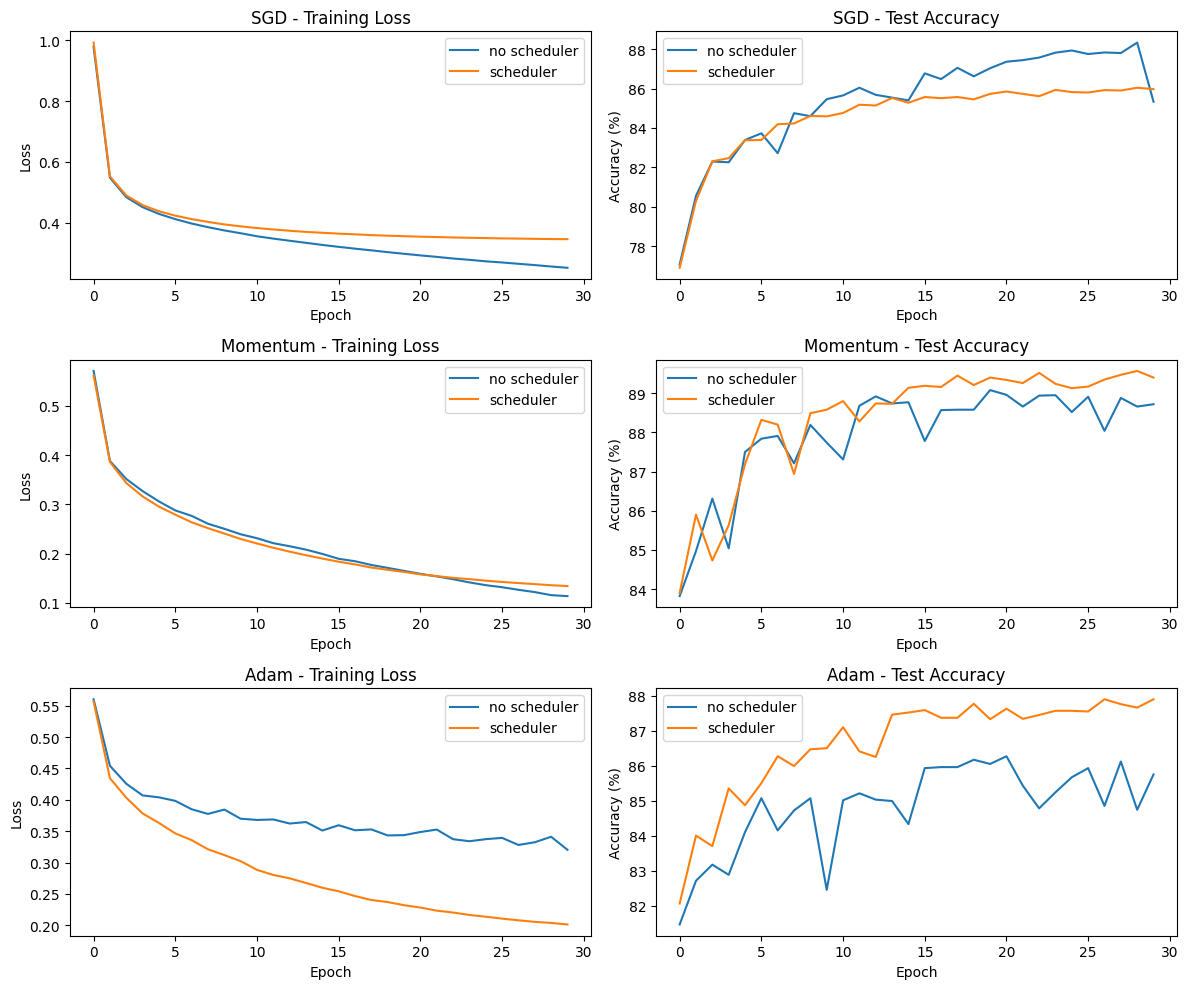

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 데이터셋 로딩
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

# 모델 정의
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

# 학습 함수
def train_model(optimizer_name, use_scheduler=False, lr=0.01, epochs=30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleNN().to(device)
    criterion = nn.CrossEntropyLoss()

    # Optimizer 설정
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("지원하지 않는 Optimizer입니다.")

    # 스케줄러 설정
    if use_scheduler:
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    train_loss = []
    test_acc = []

    print(f"\n[{'scheduler' if use_scheduler else 'no scheduler'}] {optimizer_name} 학습 시작")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader)
        train_loss.append(avg_loss)

        # 정확도 계산
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = correct / total
        test_acc.append(accuracy)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Accuracy={accuracy*100:.2f}%")

        if use_scheduler:
            scheduler.step()

    return train_loss, test_acc

# 실험 실행
optimizers = ['SGD', 'Momentum', 'Adam']
results = {}

for opt in optimizers:
    loss1, acc1 = train_model(opt, use_scheduler=False)
    loss2, acc2 = train_model(opt, use_scheduler=True)
    results[opt] = {
        'no_scheduler': {'loss': loss1, 'acc': acc1},
        'scheduler': {'loss': loss2, 'acc': acc2}
    }

# 시각화
plt.figure(figsize=(12, 10))
for i, opt in enumerate(optimizers):
    plt.subplot(3, 2, i*2+1)
    plt.plot(results[opt]['no_scheduler']['loss'], label='no scheduler')
    plt.plot(results[opt]['scheduler']['loss'], label='scheduler')
    plt.title(f'{opt} - Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(3, 2, i*2+2)
    plt.plot([a*100 for a in results[opt]['no_scheduler']['acc']], label='no scheduler')
    plt.plot([a*100 for a in results[opt]['scheduler']['acc']], label='scheduler')
    plt.title(f'{opt} - Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

plt.tight_layout()
plt.show()